In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("..//Data//core_doctor.csv")

In [3]:
df.head()

,name,id,qualification,designation,age,mobile_no,email,registration_number,facility_id,specialization_id
0,Dr. Ritu Das,6604,MBBS DNB -Obst. & Gynae,Consultant,26 Yrs,9831113793,NaN,56402,17,65
1,Dr. Gondaliya Hetashvi Hasmukhvhai,7817,DNB- Endocrinology,Associate Consultant,43 Yrs,8128062210,gondaliya.hasmukhvhai@ckbirlahospitals.com,77158,16,64
2,Dr. Anukriti Sood,7490,"M.S., MCh (Breast and Endocrine Surgery) (AIIMS)",Consultant,39 Yrs,8058233200,NaN,35533/23527,16,88
3,Dr. Rashmi Gupta,5296,NaN,Visiting Consultants,35 Yrs,9999999999,NaN,D1269,16,86
4,Dr. Anshu Chaturvedi,5192,Masterin Food & Human Nutritio,Senior Dietician,36 Yrs,8561991959,NaN,D192,16,82


In [ ]:
import pandas as pd
import numpy as np

# Function to convert to numerical years
def convert_age(value):
    value = value.strip().lower()
    if 'yrs' in value:
        return float(value.replace('yrs', '').strip())
    elif 'mnts' in value:
        return float(value.replace('mnts', '').strip()) / 12
    else:
        return np.nan  # in case of missing or unexpected format

# Apply conversion
df['age_num'] = df['age'].apply(convert_age)

In [6]:
df.head()

,name,id,qualification,designation,age,mobile_no,email,registration_number,facility_id,specialization_id,age_num
0,Dr. Ritu Das,6604,MBBS DNB -Obst. & Gynae,Consultant,26 Yrs,9831113793,NaN,56402,17,65,26.0
1,Dr. Gondaliya Hetashvi Hasmukhvhai,7817,DNB- Endocrinology,Associate Consultant,43 Yrs,8128062210,gondaliya.hasmukhvhai@ckbirlahospitals.com,77158,16,64,43.0
2,Dr. Anukriti Sood,7490,"M.S., MCh (Breast and Endocrine Surgery) (AIIMS)",Consultant,39 Yrs,8058233200,NaN,35533/23527,16,88,39.0
3,Dr. Rashmi Gupta,5296,NaN,Visiting Consultants,35 Yrs,9999999999,NaN,D1269,16,86,35.0
4,Dr. Anshu Chaturvedi,5192,Masterin Food & Human Nutritio,Senior Dietician,36 Yrs,8561991959,NaN,D192,16,82,36.0


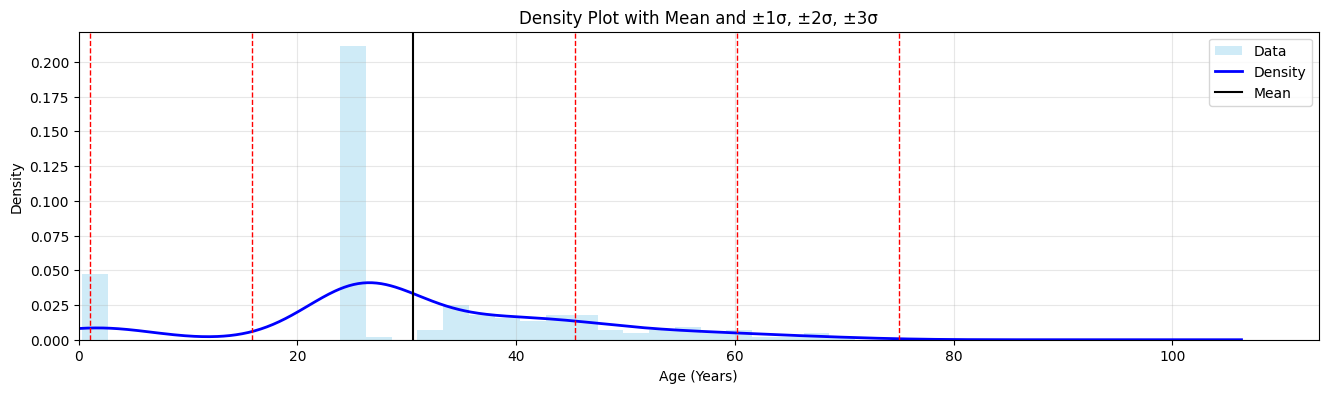

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Compute mean and standard deviation
mean = df['age_num'].mean()
std = df['age_num'].std()

# Plot histogram + density curve
plt.figure(figsize=(16, 4))
plt.hist(df['age_num'], bins=30, density=True, alpha=0.4, color='skyblue', label='Data')
df['age_num'].plot(kind='kde', color='blue', linewidth=2, label='Density')

# Add mean and ±SD lines
plt.axvline(mean, color='black', linestyle='-', linewidth=1.5, label='Mean')
for i in range(1, 4):
    plt.axvline(mean + i*std, color='red', linestyle='--', linewidth=1)
    plt.axvline(mean - i*std, color='red', linestyle='--', linewidth=1)

# Labels and legend
plt.title('Density Plot with Mean and ±1σ, ±2σ, ±3σ')
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(left=0)   # Optional: prevent negative x-axis
plt.show()

In [18]:
print((df['age_num'] < 0).sum())

0


In [19]:
df.shape

(189, 11)

In [20]:
df[70:75]

,name,id,qualification,designation,age,mobile_no,email,registration_number,facility_id,specialization_id,age_num
70,Dr. Ratan Kumar Das,66,NaN,Director,2 Yrs,9831987675,drratan.das@ckbirlahospitals.com,71820(WBMC),15,4,2.0
71,Dr. Manoj Kumar Daga,65,NaN,Director,2 Yrs,9432640148,drmanoj.daga@ckbirlahospitals.com,71695 (WBMC),15,4,2.0
72,Dr. Soumya Guha,7628,NaN,Senior Consultant,38 Yrs,9999790836,NaN,92506(WBMC),15,4,38.0
73,Dr. Bikash B / Dr Swarnali D,6566,"MBBS, DGO, MD - Obst. & Gynae",Director,68 Yrs,9231648138,NaN,41195,17,65,68.0
74,Dr. Lipika Das Mukhopadhyay,6683,MBBS MS - Obst. & Gynae,Consultant,26 Yrs,9836268454,NaN,56483,17,65,26.0


In [25]:
df[['Actual_Name', 'Extra_Name']] = df['name'].str.split('/', n=1, expand=True)
df['Actual_Name'] = df['Actual_Name'].str.strip()
df['Extra_Name'] = df['Extra_Name'].str.strip()

In [26]:
df.head()

,name,id,qualification,designation,age,mobile_no,email,registration_number,facility_id,specialization_id,age_num,Actual_Name,Extra_Name
0,Dr. Ritu Das,6604,MBBS DNB -Obst. & Gynae,Consultant,26 Yrs,9831113793,NaN,56402,17,65,26.0,Dr. Ritu Das,None
1,Dr. Gondaliya Hetashvi Hasmukhvhai,7817,DNB- Endocrinology,Associate Consultant,43 Yrs,8128062210,gondaliya.hasmukhvhai@ckbirlahospitals.com,77158,16,64,43.0,Dr. Gondaliya Hetashvi Hasmukhvhai,None
2,Dr. Anukriti Sood,7490,"M.S., MCh (Breast and Endocrine Surgery) (AIIMS)",Consultant,39 Yrs,8058233200,NaN,35533/23527,16,88,39.0,Dr. Anukriti Sood,None
3,Dr. Rashmi Gupta,5296,NaN,Visiting Consultants,35 Yrs,9999999999,NaN,D1269,16,86,35.0,Dr. Rashmi Gupta,None
4,Dr. Anshu Chaturvedi,5192,Masterin Food & Human Nutritio,Senior Dietician,36 Yrs,8561991959,NaN,D192,16,82,36.0,Dr. Anshu Chaturvedi,None


In [28]:
# Get row indices where name_2 is not null
row_indices = df.index[df['Extra_Name'].notna()].tolist()

print(row_indices)

[7, 8, 13, 17, 30, 36, 43, 46, 73]
